In [1]:
!pip install gymnasium

In [2]:
!pip install gymnasium

In [3]:
import gymnasium as gym
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

In [4]:
env = gym.make("Blackjack-v1")

In [5]:
state, _ = env.reset()

print(state)

(13, 7, 0)


In [6]:
(18, 10, False)

(18, 10, False)

In [7]:
state, _ = env.reset()

done = False

while not done:

    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    print("State:", state)
    print("Action:", action)
    print("Reward:", reward)
    print("----------------")

    state = next_state

State: (12, 2, 0)
Action: 1
Reward: 0.0
----------------
State: (16, 2, 0)
Action: 1
Reward: -1.0
----------------


In [8]:
# 0 = Stick
# 1 = Hit

In [9]:
Q = defaultdict(lambda: np.zeros(env.action_space.n))

returns = defaultdict(list)

policy = defaultdict(int)

In [10]:
def epsilon_greedy_policy(state, epsilon=0.1):

    if random.uniform(0, 1) < epsilon:
        return env.action_space.sample()

    return np.argmax(Q[state])

In [11]:
def generate_episode(epsilon=0.1):

    episode = []

    state, _ = env.reset()

    done = False

    while not done:

        action = epsilon_greedy_policy(state, epsilon)

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        episode.append((state, action, reward))

        state = next_state

    return episode

In [13]:
num_episodes = 50000   # Reduced episodes

for i in range(num_episodes):

    episode = generate_episode()

    G = 0

    for state, action, reward in reversed(episode):

        G += reward

        Q[state][action] += 0.01 * (G - Q[state][action])

        policy[state] = np.argmax(Q[state])

    if i % 5000 == 0:
        print(f"Episode {i} completed")

Episode 0 completed
Episode 5000 completed
Episode 10000 completed
Episode 15000 completed
Episode 20000 completed
Episode 25000 completed
Episode 30000 completed
Episode 35000 completed
Episode 40000 completed
Episode 45000 completed


In [14]:
wins = 0
losses = 0
draws = 0

test_games = 10000

for _ in range(test_games):

    state, _ = env.reset()

    done = False

    while not done:

        action = policy[state]

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        state = next_state

    if reward == 1:
        wins += 1

    elif reward == -1:
        losses += 1

    else:
        draws += 1

print("Wins:", wins)
print("Losses:", losses)
print("Draws:", draws)

Wins: 4247
Losses: 4847
Draws: 906


In [15]:
win_rate = wins / test_games * 100

print("Win Rate:", win_rate, "%")

Win Rate: 42.47 %


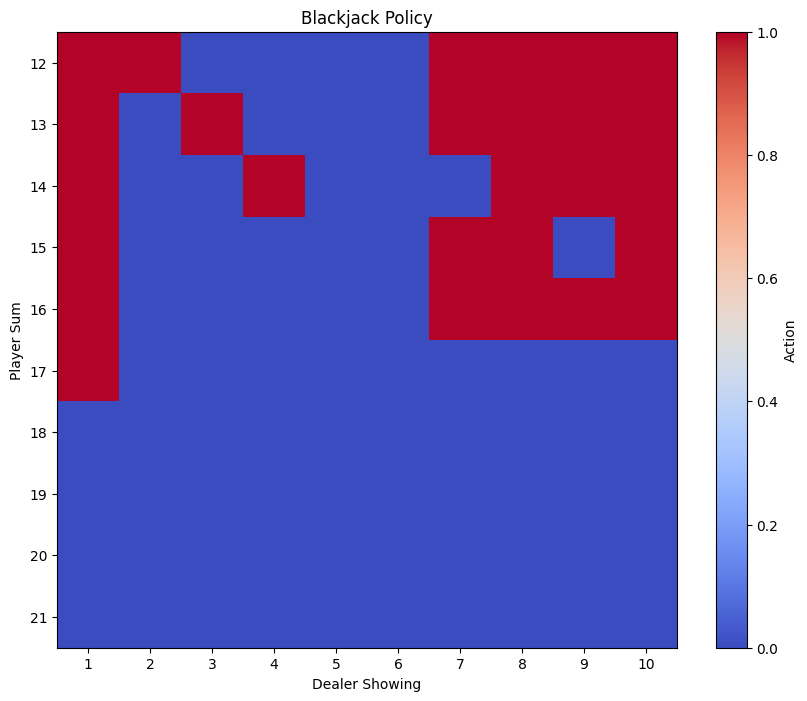

In [16]:
player_sums = np.arange(12, 22)
dealer_showing = np.arange(1, 11)

policy_grid = np.zeros((10, 10))

for i, player in enumerate(player_sums):
    for j, dealer in enumerate(dealer_showing):

        state = (player, dealer, False)

        policy_grid[i, j] = policy[state]

plt.figure(figsize=(10, 8))

plt.imshow(policy_grid, cmap='coolwarm', aspect='auto')

plt.colorbar(label="Action")

plt.xticks(range(10), dealer_showing)
plt.yticks(range(10), player_sums)

plt.xlabel("Dealer Showing")
plt.ylabel("Player Sum")

plt.title("Blackjack Policy")

plt.show()